# ✨Evaluating spectral reflectance separability✨

This notebook can be used to evaluate spectral separability of point-source spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## __________________________________________________________________________________________________________________________________________________________
##
## 🔨 Set-up 
Importing modules and data

In [75]:
# Import required scripts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as prep
from scipy.signal import find_peaks as fp
from scipy.signal import savgol_filter
import itertools
from scipy.cluster.hierarchy import fcluster, linkage
import peaks_analysis as pa
import jenkspy
import pywt
import claude_hyper_denoiser as chd
import scipy


In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [ ]:
# import sys
# !{sys.executable} -m pip install PyWavelets


## __________________________________________________________________________________________________________________________________________________________
##
##  🏭 Preprocessing

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes. If a scaler is chosen, it will scale the data accordingly.

In [3]:
# Define preprocessing parameters for hyperspectral data
full_res_path = r"C:\Users\s4770224\Documents\GitHub\Spectral-Analysis\data\MEL_NZ_TAS_spectra.csv"
resample_path = r"data\resampled\Skysat_resampled.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "minmax"
target_scheme = "all"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [4]:
#Run the preprocessing chain (hyperspectral data only)
prepper = prep.PreprocessRefl(data_path = full_res_path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra_norm
labels_prepped = prepper.labels_filtered

Data filtered from 388 to 388 spectra.


In [5]:
# Check out the first rows and columns of your data/labels
print(spectra_prepped.iloc[:5, :5])
print(labels_prepped.head())

          460       461       462       463       464
244  0.003382  0.005401  0.002351  0.000000  0.001434
246  0.002926  0.003958  0.002013  0.000404  0.001017
291  0.000645  0.001265  0.000381  0.000000  0.001157
290  0.000863  0.001832  0.000728  0.000000  0.000786
289  0.000178  0.001609  0.000755  0.000000  0.000709
       Class     setup         site    ko   kom  kbom          bom kbrgm
244  undaria  handheld  new_zealand  kelp  kelp  kelp  brown_algae  kelp
246  undaria  handheld  new_zealand  kelp  kelp  kelp  brown_algae  kelp
291  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp
290  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp
289  undaria  handheld     tasmania  kelp  kelp  kelp  brown_algae  kelp


# Testing Stats

In [6]:
# Make class means by genus and site from preprocessed data
df = pd.concat([labels_prepped[["Class", "site"]], spectra_prepped], axis = 1)
means = df.groupby(["Class", "site"]).mean().transpose()
means.index = means.index.astype("int64")

In [7]:
# Apply smoothing filter and reformat
smoothed = pd.DataFrame(savgol_filter(means, axis = 0, window_length= 5, polyorder= 1)) 
smoothed.index = means.index
smoothed.columns = means.columns

# Calculate first derivative and reformat
deriv_1 = pd.DataFrame(savgol_filter(means*100, axis = 0, window_length= 10, polyorder= 1, deriv = 1))
deriv_1.index = means.index
deriv_1.columns = means.columns

In [ ]:
import claude_hyper_denoiser as chd
denoiser = chd.HyperspectralWaveletDenoiser()
denoiser.denoise_profile(smoothed.iloc[:,1])

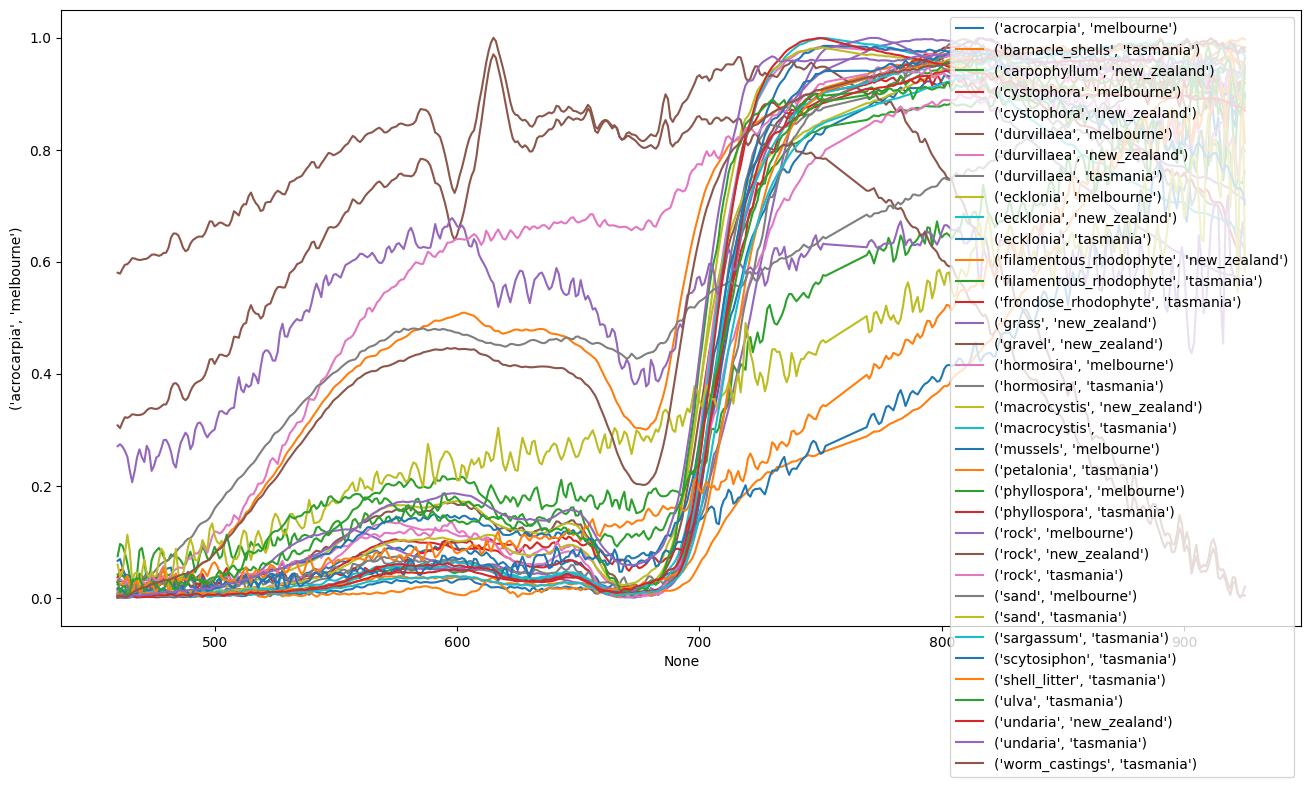

In [87]:
# Choose data to plot
plotting_data = means

# Plot all classes in the data
plt.figure(figsize = (16, 8))

for col in plotting_data.columns: 
    sns.lineplot(data = plotting_data, x = plotting_data.index, y = plotting_data.loc[:, col], label = col) 
plt.legend()
plt.show()

In [ ]:
diff = np.diff(smoothed.iloc[:,0].dropna(axis = 0, how = "any"))
sigma = np.std(diff) / np.sqrt(2)
coeffs = pywt.wavedec(smoothed.iloc[:,0].dropna(axis = 0, how = "any"), 'db8')
# threshold = sigma * np.sqrt(2 * np.log(len(smoothed.iloc[:,0])))
# coeffs_thresh = [pywt.threshold(c, threshold, "hard") for c in coeffs]
threshold = sigma * np.sqrt(2 * np.log(len(smoothed.iloc[:,0].dropna(axis = 0, how = "any"))))
coeffs_thresh = list(coeffs)
coeffs_thresh[1:] = [pywt.threshold(c, threshold, "soft") for c in coeffs[1:]]
recon = pywt.waverec(coeffs_thresh, 'db8')

In [68]:
denoised_dict = {} 
means = means.dropna(axis = 0, how = "any")
for item in means.items():
    denoised_dict[item[0]] = chd.denoise_spectrum(item[1], wavelet = "db8")

C:\Users\s4770224\AppData\Local\Temp\ipykernel_36692\1396279126.py:2: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(means.index, item[1], label = item[0])


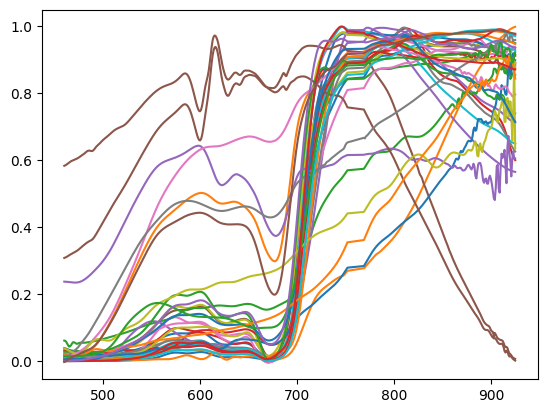

In [70]:
for item in denoised_dict.items():
    plt.plot(means.index, item[1], label = item[0])
plt.show()

In [76]:
derivatives = {}
for item in denoised_dict.items():
    derivatives[item[0]] = np.gradient(item[1])

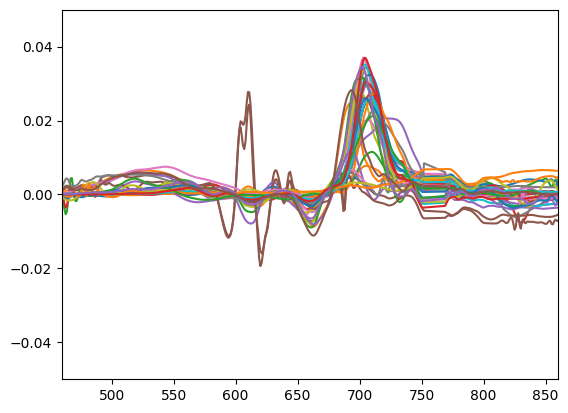

In [83]:
for item in derivatives.items():
    plt.plot(means.index, item[1])
plt.ylim(-0.05, 0.05)
plt.xlim(460, 860)
plt.show()

In [84]:
# Identify reflectance minima and maxima
features_dict = {}
for item in denoised_dict.items():
    crossings = pa.find_zero_crossings(deriv_1.loc[:, col])
    features_dict[col] = crossings

#Inspect the features
for item in features_dict.items():
   print(f" {item[0]} has {len(item[1])} spectral features")


 ('worm_castings', 'tasmania') has 43 spectral features


In [85]:
denoised_dict[("worm_castings","tasmania")]

array([-2.62189682e-03, -1.34493347e-03,  3.35338968e-04,  2.37562002e-03,
        4.63298075e-03,  6.80449714e-03,  8.69557666e-03,  1.02529977e-02,
        1.14910128e-02,  1.26153583e-02,  1.37880052e-02,  1.49288090e-02,
        1.60573453e-02,  1.72737202e-02,  1.85988348e-02,  2.01075467e-02,
        2.17878545e-02,  2.34184581e-02,  2.48776257e-02,  2.62226982e-02,
        2.74700659e-02,  2.86789388e-02,  2.99209891e-02,  3.11294700e-02,
        3.23062151e-02,  3.35654119e-02,  3.49615174e-02,  3.65335892e-02,
        3.83261697e-02,  4.03185760e-02,  4.25078864e-02,  4.49506003e-02,
        4.76663695e-02,  5.06468812e-02,  5.38911879e-02,  5.73706961e-02,
        6.10480986e-02,  6.48959236e-02,  6.88835452e-02,  7.29923157e-02,
        7.72196852e-02,  8.15800006e-02,  8.60805107e-02,  9.06993392e-02,
        9.54232707e-02,  1.00246670e-01,  1.05156994e-01,  1.10154060e-01,
        1.15227894e-01,  1.20344509e-01,  1.25488665e-01,  1.30673020e-01,
        1.35913519e-01,  

In [10]:
# Filter all features based on a maximum euclidean distance for clustering
filtered_features = {}
for item in features_dict.items():
    filtered_features[item[0]] = pa.filter_crossings_hierarchical(crossings = item[1], derivative=deriv_1[item[0]], max_distance=10, method = "single")


(array([ 5.,  7.,  4.,  1.,  3., 13.,  2.,  1.,  4.,  0.,  1.,  2.,  3.,
         1.,  2.,  1.,  0.,  0.,  1.,  2.,  2.,  0.,  1.,  3.,  6.,  5.,
        17.,  3.,  4., 16.,  4.,  2.,  8.,  1.,  3.,  5., 15.,  9.,  2.,
        21.,  2.,  1.,  1.,  4., 10., 13.,  5.,  1.,  1.,  3.,  0.,  0.,
         3.,  1.,  1.,  0.,  1.,  1.,  2.,  2.,  5.,  0., 32.,  0.,  0.,
         0.,  0.,  0.,  0.,  3.,  3.,  2.,  1.,  1.,  6.,  5.,  2.,  8.,
         2.,  3.,  3.,  1.,  2.,  2.,  4.,  2.,  4.,  3.,  5.,  4.,  2.,
         1.,  4.,  3.,  4.,  4.,  2.,  6.,  6.,  8.]),
 array([465.  , 469.53, 474.06, 478.59, 483.12, 487.65, 492.18, 496.71,
        501.24, 505.77, 510.3 , 514.83, 519.36, 523.89, 528.42, 532.95,
        537.48, 542.01, 546.54, 551.07, 555.6 , 560.13, 564.66, 569.19,
        573.72, 578.25, 582.78, 587.31, 591.84, 596.37, 600.9 , 605.43,
        609.96, 614.49, 619.02, 623.55, 628.08, 632.61, 637.14, 641.67,
        646.2 , 650.73, 655.26, 659.79, 664.32, 668.85, 673.38, 677.91,
  

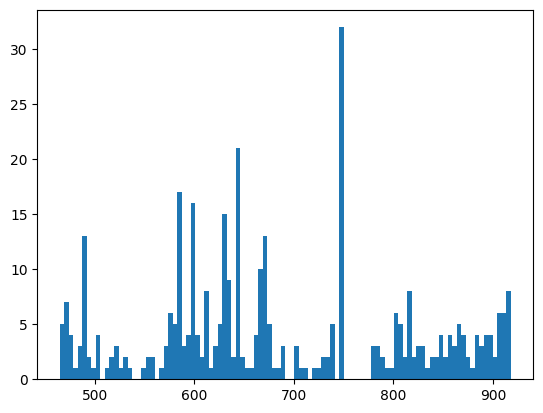

In [11]:
# Aggregate all filtered features into a single list 
features_list = [] 
for item in filtered_features.items():
    features_list.append(list(item[1][:,0]))
features_list = [x for xs in features_list for x in xs]

# Count feature flags
values, counts = np.unique(features_list, return_counts= True)
feature_counts = pd.DataFrame({"nm": values, "count": counts})
feature_counts

plt.hist(features_list, bins = 100)

In [12]:
jnb = jenkspy.JenksNaturalBreaks(10)
jnb.fit(features_list)
print( jnb.labels_)
print(jnb.groups_)
print(jnb.breaks_)

[0 2 3 4 4 5 6 7 8 9 3 4 5 6 7 8 0 1 2 3 3 4 4 5 6 7 8 9 9 0 0 2 3 4 4 5 6
 6 7 0 0 2 3 4 4 5 6 7 0 0 2 3 4 4 5 6 7 8 9 9 9 0 0 2 4 4 5 6 7 8 9 0 2 3
 4 4 5 6 6 7 2 2 3 4 4 5 6 7 8 0 0 1 2 4 4 5 6 0 1 1 2 2 3 4 4 5 6 7 8 9 1
 2 3 3 4 4 5 6 0 0 1 1 2 2 2 4 5 6 7 7 7 9 0 1 3 4 4 5 6 7 7 9 0 2 3 3 5 6
 0 2 3 3 4 5 5 5 6 9 0 2 3 4 4 5 6 7 7 8 9 9 1 2 4 5 6 7 7 8 8 9 0 3 3 4 4
 5 6 7 8 9 0 2 3 4 4 5 6 7 8 9 1 2 3 4 5 6 6 6 7 9 9 0 3 4 5 6 7 8 9 0 2 3
 4 4 5 6 7 8 8 9 0 2 3 4 4 5 6 7 8 8 9 0 0 2 2 3 4 5 5 6 7 7 8 9 0 1 1 2 3
 3 4 4 5 5 6 6 9 9 3 4 5 6 7 8 8 9 9 3 3 4 4 5 6 6 9 0 1 2 2 4 5 5 6 6 7 7
 7 8 8 9 0 2 3 4 4 5 6 9 0 0 2 3 4 5 6 7 8 8 8 9 0 1 2 2 4 5 5 6 6 8 9 9 0
 2 2 3 3 4 4 5 6 7 7 7 8 9 0 0 2 3 4 4 5 6 8 8 9 2 3 4 4 5 6 7 7 7 9 9 3 4
 5 6 7 8 9]
[array([489., 488., 473., 490., 470., 491., 466., 490., 473., 496., 499.,
       470., 489., 485., 466., 477., 466., 476., 487., 490., 489., 489.,
       492., 478., 474., 473., 496., 488., 476., 489., 465., 486., 472.,
       483., 469.,

In [18]:

# Usage:
denoised = denoise_spectrum(smoothed.iloc[:,0])

In [57]:
sigma = np.std(list(diff)) / np.sqrt(2)
np.std(diff, axis = 0)

0.006078240794889236

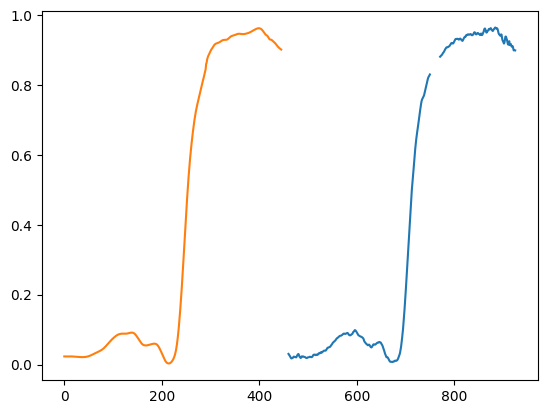

In [58]:
plt.plot(smoothed.iloc[:,0])
plt.plot(recon)
plt.show()

In [ ]:
# reshape = values.reshape(-1,1)
# linkage_matrix = linkage(reshape, method = "centroid")
# clusters = fcluster(linkage_matrix, t=10, criterion='distance')
# clusters

reshape = np.array(features_list).reshape(-1,1)
linkage_matrix = linkage(reshape, method = "complete")
clusters = fcluster(linkage_matrix, t=15, criterion='distance')
clusters

In [365]:
filtered = []
for cluster_id in np.unique(clusters):
    cluster_crossings = reshape[clusters == cluster_id]
    filtered.append(int(np.mean(cluster_crossings)) )

In [ ]:
print(np.diff(np.sort(filtered)))
print(np.sort(filtered))

In [ ]:
# Calculate absolute value of derivative
absolute = np.absolute(deriv_1)

# Find peaks in peaks_data val of derivative
peaks_data = smoothed
col = 34
h = None
prom = 0.001
dist = 5
w = 5
rel_h = 0.5
peaks, properties = fp(x = peaks_data.iloc[:, col], 
                       height = h, 
                       prominence= prom,
                       distance = dist,
                       width = w,
                       rel_height = rel_h, 
                       )
len(peaks)

# Plot peaks_data and identified peaks
sns.lineplot(data = peaks_data, x = peaks_data.index, y = peaks_data.iloc[:, col] )
sns.scatterplot(data = peaks_data.iloc[peaks], x = peaks_data.iloc[peaks].index, y = peaks_data.iloc[peaks, col], color = "red")
sns.scatterplot(data = peaks_data.iloc[crossings], x = peaks_data.iloc[crossings].index, y = peaks_data.iloc[crossings, col], color = "green")
sns.scatterplot(data = peaks_data.iloc[f], x = peaks_data.iloc[f].index, y = peaks_data.iloc[f, col], color = "yellow", size = 12)
sns.scatterplot(data = peaks_data.loc[features["nm"], :], x = peaks_data.loc[features["nm"]].index, y = peaks_data.iloc[features[0], col], color = "black", size = 8)
plt.show()


In [344]:
deriv_1.dropna(axis = 0, inplace = True)
crossings = pa.find_zero_crossings(deriv_1.iloc[:, 34])

In [345]:
exam = pd.DataFrame([crossings, np.diff(crossings), deriv_1.iloc[crossings, 34]]).transpose()

In [ ]:
features = exam[exam[1] > 5]
features["nm"] = peaks_data.iloc[features[0]].index